In [1]:
import pandas as pd
import pickle as pkl
import json
from manifold import reaction_time as mrx
from matplotlib import pyplot as plt
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# with open("../data/external/motivation_scalars", "rb") as f:
#     engagement_pickles_one = json.load(f)

# with open("../data/external/motivation_scalars_validate", "rb") as f:
#     engagement_pickles_two = json.load(f)

# with open("../data/external/motivation_scalars_test", "rb") as f:
#     engagement_pickles_three = json.load(f)

# engagement_pickle = engagement_pickles_one | engagement_pickles_two | engagement_pickles_three

# with open("../data/external/all_eids_engagement.pkl", "wb") as f:
#     pkl.dump(engagement_pickle, f)

In [4]:
with open("../data/processed/glm-hmm-output/action_kernel_trials.pkl", "rb") as f:
    action_kernel_pickle = pkl.load(f)

In [6]:
with open("../data/external/all_eids_engagement.pkl", "rb") as f:
    engagement_pickle = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../data/external/all_eids_engagement.pkl'

In [7]:
all_animals_df = []

for eid in action_kernel_pickle.keys():
    try:
        _, _, df_all = mrx.load_trials_sebi_engagement(
            engagement_pickle, action_kernel_pickle, eid
        )
        # eid = trial_files[idx].rsplit("/")[-2]
        df_all["animal_id"] = eid
        all_animals_df.append(df_all)
        # plt.hist(df_all["engagement"])
        # plt.show()
    except Exception as e:
        print(e)

np.str_('283ecb4c-e529-409c-9f0a-8ea5191dcf50')
np.str_('d71e565d-4ddb-42df-849e-f99cfdeced52')


In [8]:
cohort_df = pd.concat(all_animals_df)

In [9]:
def normalize_engagement(df):
    group = df.groupby("animal_id")["engagement"]
    df["engagement_norm"] = (df["engagement"] - group.transform("min")) / (
        group.transform("max") - group.transform("min")
    )
    df["engagement_state"] = df.groupby("animal_id")["engagement_norm"].transform(
        lambda x: pd.qcut(x, q=3, labels=[0, 1, 2])
    )
    level_map = {0: "Low", 1: "Medium", 2: "High"}
    df["engagement_label"] = df["engagement_state"].map(level_map)
    # df["animal_median"] = df.groupby("animal_id")["engagement"].transform("median")
    # df["engagement_state"] = (df["engagement"] >= df["animal_median"]).astype(int)
    return df

In [10]:
cohort_df = normalize_engagement(cohort_df)

In [11]:
cohort_df = cohort_df.reset_index()

In [15]:
cohort_df.keys()

Index(['index', 'goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1',
       'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times',
       'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'intervals_0', 'intervals_1', 'prior',
       'prediction_error_left', 'prediction_error_right', 'engagement',
       'rt_sec', 'stimulus_side', 'absolute_contrast', 'expected_side',
       'internal_congruent', 'Congruence_Label', 'signed_contrast',
       'Prior_Label', 'contrast_ordinal', 'is_correct', 'rolling_accuracy',
       'proxy_state_label', 'animal_id', 'engagement_norm', 'engagement_state',
       'engagement_label'],
      dtype='object')

In [16]:
# cohort_df_correct = cohort_df[cohort_df["feedbackType"] == 1.0].copy()
# cohort_df_incorrect = cohort_df[cohort_df["feedbackType"] == -1.0].copy()

# cohort_rt_overall = (
#     cohort_df_correct.groupby(["animal_id", "contrast_ordinal", "Prior_Label"])["rt_sec"]
#     .median()
#     .reset_index()
# )

# cohort_counts_overall = (
#     cohort_df_correct.groupby(["contrast_ordinal", "Prior_Label"])
#     .size()
#     .reset_index(name="n_trials")
# )

# cohort_rt_correct_state = (
#     cohort_df_correct.groupby(
#         ["animal_id", "contrast_ordinal", "Prior_Label", "engagement_state"]
#     )["rt_sec"]
#     .median()
#     .reset_index()
# )

# cohort_counts_correct_state = (
#     cohort_df_correct.groupby(["contrast_ordinal", "Prior_Label", "engagement_state"])
#     .size()
#     .reset_index(name="n_trials")
# )

# cohort_rt_incorrect_state = (
#     cohort_df_incorrect.groupby(
#         ["animal_id", "contrast_ordinal", "Prior_Label", "engagement_state"]
#     )["rt_sec"]
#     .median()
#     .reset_index()
# )

# cohort_counts_incorrect_state = (
#     cohort_df_incorrect.groupby(["contrast_ordinal", "Prior_Label", "engagement_state"])
#     .size()
#     .reset_index(name="n_trials")
# )

# ylim = (0.1, 0.8)

In [17]:
# mrx.plot_cohort_overall_rt(cohort_rt_overall, cohort_counts_overall, ylim)

In [18]:
# mrx.plot_cohort_rt_by_engagement(
#     cohort_rt_correct_state,
#     cohort_counts_correct_state,
#     title="Correct Trials",
#     ylim=ylim,
#     state_idx="engagement_state",
# )

In [19]:
# mrx.plot_cohort_rt_by_engagement(
#     cohort_rt_incorrect_state,
#     cohort_counts_incorrect_state,
#     title="Incorrect Trials",
#     drop_errors=False,
#     ylim=ylim,
#     state_idx="engagement_state",
# )

In [43]:
results_meancentered = mrx.run_all_behavioral_lmms_continuous(df_cohort=cohort_df)

Engagement Mean: 0.651 (This is now your 0 point)

============ Correct Trials: Main Effects ============
                                Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                rt_sec     
No. Observations:                159671                 Method:                            REML       
No. Groups:                      334                    Scale:                             0.0758     
Min. group size:                 181                    Log-Likelihood:                    -21319.7119
Max. group size:                 1363                   Converged:                         Yes        
Mean group size:                 478.1                                                                
------------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]


In [20]:
results = mrx.run_all_behavioral_lmms_continuous(df_cohort=cohort_df)

Engagement Mean: 0.651 (This is now your 0 point)

============ Correct Trials: Main Effects ============
                                Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                rt_sec     
No. Observations:                159671                 Method:                            REML       
No. Groups:                      334                    Scale:                             0.0758     
Min. group size:                 181                    Log-Likelihood:                    -21319.7119
Max. group size:                 1363                   Converged:                         Yes        
Mean group size:                 478.1                                                                
------------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]


In [36]:
results

{'main_effects': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x179c4c400>,
 '2_way_interaction': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x175c7ff10>,
 '3_way_interaction': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x175c7ff40>}

In [21]:
import seaborn as sns

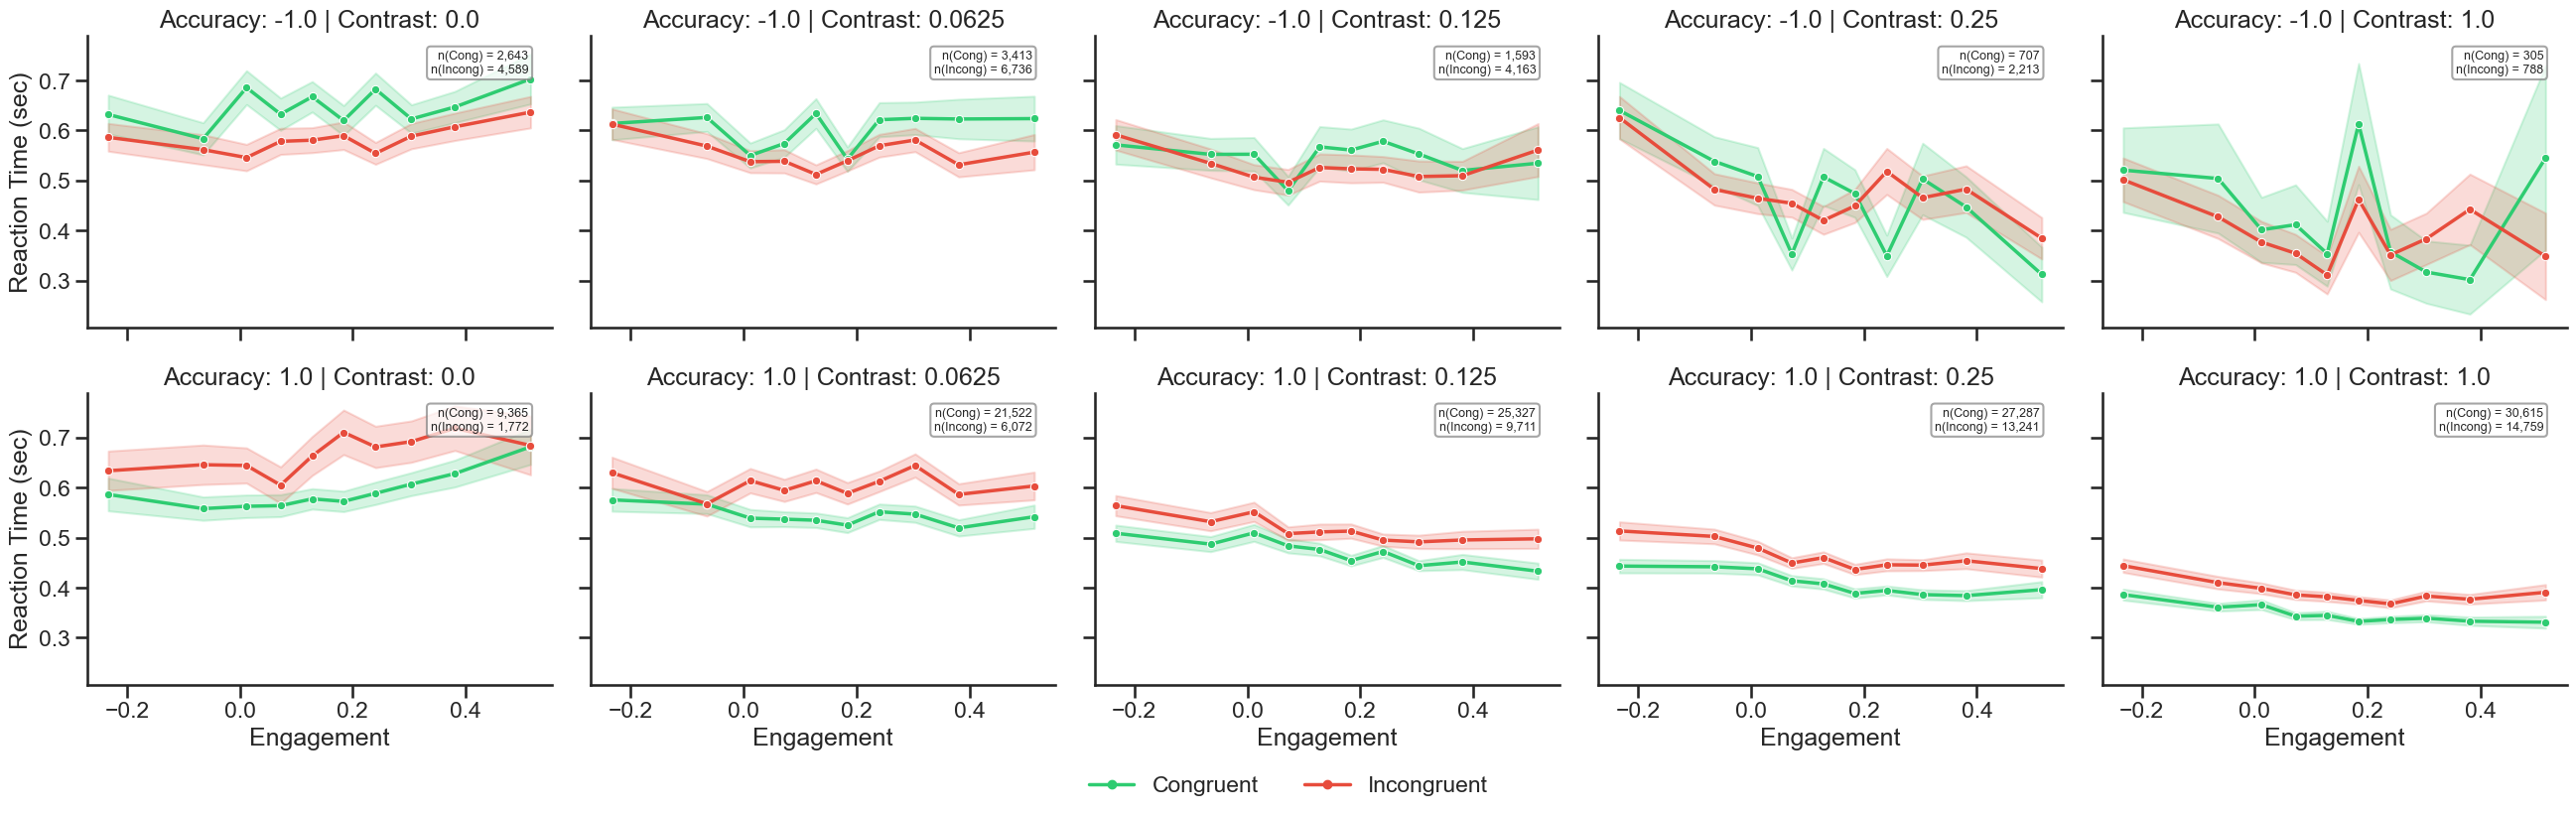

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create 10 equal-sized bins for engagement (Deciles)
df = cohort_df.copy()
# Using qcut ensures each bin has roughly the same number of trials
df["engagement_bin"] = pd.qcut(df["engagement"], q=10, labels=False)

# 2. Map the actual mean engagement value of each bin for a realistic X-axis
bin_means = df.groupby("engagement_bin")["engagement"].mean()
df["engagement_plot_x"] = df["engagement_bin"].map(bin_means)

# 3. CRITICAL STEP: Average the trials for EACH ANIMAL first
# This prevents animals with more trials from skewing the visual average
animal_means = (
    df.groupby(
        [
            "animal_id",
            "engagement_plot_x",
            "Congruence_Label",
            "absolute_contrast",
            "feedbackType",
        ]
    )["rt_sec"]
    .mean()
    .reset_index()
)

# 4. Plot the animal averages
sns.set_theme(style="ticks", context="talk")

# relplot with kind="line" will automatically average across animals
# and draw the standard error (SEM) bands around the lines
g = sns.relplot(
    data=animal_means,
    x="engagement_plot_x",
    y="rt_sec",
    hue="Congruence_Label",
    col="absolute_contrast",
    row="feedbackType",
    kind="line",
    marker="o",  # Puts a dot at each of the 10 bins
    markersize=6,
    errorbar="se",  # Standard Error across animals
    palette=["#2ecc71", "#e74c3c"],
    height=4,
    aspect=1.2,
    linewidth=2.5,
)

g.set_axis_labels("Engagement", "Reaction Time (sec)")
g.set_titles(col_template="Contrast: {col_name}", row_template="Accuracy: {row_name}")

sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, title=None, frameon=False)

plt.tight_layout()

for (accuracy_val, contrast_val), ax in g.axes_dict.items():

    # 1. Filter the ORIGINAL raw dataframe (df) for this specific facet
    facet_data = df[
        (df["feedbackType"] == accuracy_val) & (df["absolute_contrast"] == contrast_val)
    ]

    # 2. Count the number of raw trials for each congruence type
    n_congruent = len(facet_data[facet_data["Congruence_Label"] == "Congruent"])
    n_incongruent = len(facet_data[facet_data["Congruence_Label"] == "Incongruent"])

    # 3. Format the text nicely with commas for thousands
    text_label = f"n(Cong) = {n_congruent:,}\nn(Incong) = {n_incongruent:,}"

    # 4. Add the text box to the top-right corner of each facet
    # transform=ax.transAxes means x and y are fractions (0 to 1) of the subplot box
    ax.text(
        0.95,
        0.95,
        text_label,
        transform=ax.transAxes,
        fontsize=9,  # Keep it small so it doesn't block data
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7, edgecolor="gray"),
    )
# plt.savefig("clean_animal_averaged_plot.png", dpi=300, bbox_inches="tight")

In [37]:
def pretty_print_mixedlm(result, name_replacements=None):
    """
    Takes a statsmodels MixedLMResultsWrapper and prints a clean, readable table.

    Parameters:
    - result: The fitted statsmodels object (e.g., your_dict['3_way_interaction'])
    - name_replacements: A dictionary mapping ugly string fragments to clean names.
    """

    # 1. Extract the core statistics into a pandas DataFrame
    df = pd.DataFrame(
        {
            "Coefficient": result.params,
            "Std. Err.": result.bse,
            "z-score": result.tvalues,
            "P-value": result.pvalues,
        }
    )

    # 2. Extract and format Confidence Intervals
    conf_int = result.conf_int()
    df["95% CI"] = (
        "[" + conf_int[0].round(3).astype(str) + ", " + conf_int[1].round(3).astype(str) + "]"
    )

    # 3. Format numbers to 3 decimal places, and clean up P-values
    for col in ["Coefficient", "Std. Err.", "z-score"]:
        df[col] = df[col].apply(lambda x: f"{x:.3f}")

    df["P-value"] = df["P-value"].apply(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")

    # 4. Clean up the row index (variable names) using the replacement dictionary
    if name_replacements:
        clean_index = []
        for var_name in df.index:
            new_name = var_name
            # Replace the ugly fragments with clean names
            for ugly_text, clean_text in name_replacements.items():
                new_name = new_name.replace(ugly_text, clean_text)

            # Replace the statsmodels interaction colon ':' with a cleaner '×'
            new_name = new_name.replace(":", " × ")
            clean_index.append(new_name)

        df.index = clean_index

    # 5. Print a summary header
    print("======================================================================")
    print(f"Mixed Linear Model Results")
    print(
        f"Observations: {int(result.nobs)} | Groups: {int(result.k_fe)} (Wait, statsmodels handles groups differently, usually len(result.model.group_labels))"
    )
    print("======================================================================")

    # Return the clean dataframe (so it prints beautifully in a Jupyter Notebook)
    return df

In [39]:
my_clean_names = {
    "C(Congruence_Label, Treatment('Congruent'))[T.Incongruent]": "Incongruent",
    "C(Accuracy_Label, Treatment('Correct'))[T.Incorrect]": "Incorrect",
    "engagement_centered": "Engagement",
    "absolute_contrast": "Contrast",
    "Group Var": "Group Variance",
}

In [41]:
w = pretty_print_mixedlm(results["3_way_interaction"], my_clean_names)

Mixed Linear Model Results
Observations: 186821 | Groups: 9 (Wait, statsmodels handles groups differently, usually len(result.model.group_labels))


In [44]:
wprime = pretty_print_mixedlm(results_meancentered["3_way_interaction"], my_clean_names)

Mixed Linear Model Results
Observations: 186821 | Groups: 9 (Wait, statsmodels handles groups differently, usually len(result.model.group_labels))


In [45]:
wprime

,Coefficient,Std. Err.,z-score,P-value,95% CI
Intercept,0.497,0.006,78.743,< 0.001,"[0.485, 0.51]"
Incongruent,0.043,0.002,26.043,< 0.001,"[0.04, 0.046]"
Incorrect,0.115,0.003,33.953,< 0.001,"[0.108, 0.121]"
Incongruent × Incorrect,-0.102,0.004,-23.925,< 0.001,"[-0.11, -0.093]"
Engagement,-0.083,0.006,-13.813,< 0.001,"[-0.094, -0.071]"
Incongruent × Engagement,-0.047,0.009,-5.179,< 0.001,"[-0.065, -0.029]"
Engagement × Incorrect,0.040,0.018,2.216,0.027,"[0.005, 0.076]"
Incongruent × Engagement × Incorrect,0.017,0.023,0.719,0.472,"[-0.029, 0.062]"
Contrast,-0.165,0.002,-89.782,< 0.001,"[-0.169, -0.162]"
Group Variance,0.149,0.012,12.686,< 0.001,"[0.126, 0.172]"


50 sessions with widefield data found


In [7]:
with open("../data/generated/all_eids_engagement.pkl", "rb") as f:
    engagement_pickle = pkl.load(f)

In [21]:
wifi_sessions = []
all_dfs = []
for eid in sessions_all:
    details = one.get_details(eid)
    subject = details["subject"]
    sessionx = SessionLoader(one=one, eid=eid)
    sessionx.load_trials()
    trials_df = sessionx.trials.copy()
    sessionx = trials_df.assign(subject=subject)
    sessionx = sessionx.assign(session_number=session_order_dict[subject][eid])
    sessionx = sessionx.assign(session=eid)
    all_dfs.append(sessionx)

uber_df = pd.concat(all_dfs)
uber_df.to_csv(data_folder + "wifimice.csv")

wifi-subjects: 'CSK-im-001', 'CSK-im-002', 'CSK-im-009', 'CSK-im-010','CSK-im-011', 'CSK-im-012'

ModuleNotFoundError: No module named 'jax'